We will first create a set of data points which are uniformly generated from a large and small circle, as well as some 2-dimensional normal noise

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from itertools import combinations

rng = np.random.default_rng(42)

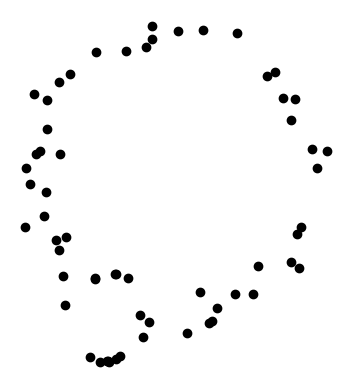

In [3]:
rng = np.random.default_rng(42)

x = np.sin(0)
y = np.cos(0)
circ1 = np.array([x,y])


circ_1_data = rng.uniform(0,1,45)
mean = [0, 0]
cov = [[0.01, 0],
       [0, 0.01]]

circ_1_noise = rng.multivariate_normal(mean, cov, 45)


for i in range(45):
    x = circ_1_data[i]
    noise = circ_1_noise[i,:]

    point = [np.sin(2*np.pi*x),np.cos(2*np.pi*x)] + noise

    circ1 = np.vstack((circ1, point))



circ_2_data = rng.uniform(0,1,15)
mean = [0, 0]
cov = [[0.0002, 0],
       [0, 0.0002]]

circ_2_noise = rng.multivariate_normal(mean, cov, 15)


for i in range(15):
    x = circ_2_data[i]
    noise = circ_2_noise[i,:]

    point = np.array([0.3*np.sin(2*np.pi*x),0.3*np.cos(2*np.pi*x)]) + np.array([-0.5,-1]) + noise

    circ1 = np.vstack((circ1, point))

plt.scatter(circ1[:,0],circ1[:,1], color="black")
plt.gca().set_aspect('equal')
plt.axis("off")

plt.show()

Now, all of our points are stored in circ1, we want to plot circles of radius epsilon and the resulting VR complex.

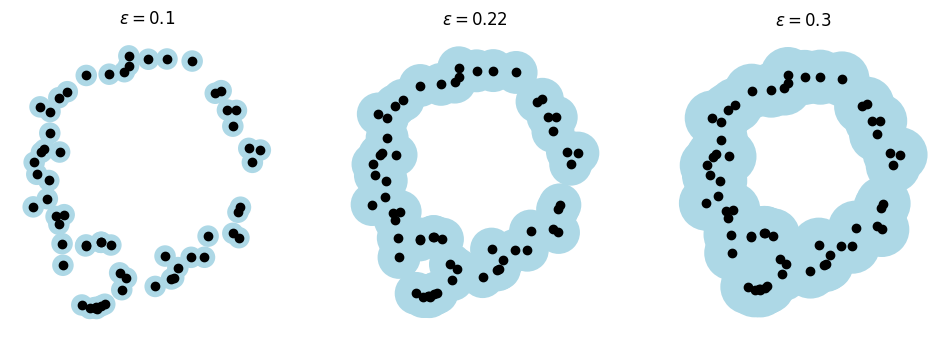

In [4]:
fig, ax = plt.subplots(1,3, figsize=(12,4))

r_range = [0.1, 0.22, 0.3]

for i in range(3):
    r = r_range[i]
    for p in circ1:
        circle = plt.Circle(
            p,
            r,
            facecolor="lightblue",
            #edgecolor="blue",
            #linewidth=1
        )
        ax[i].add_patch(circle)

    ax[i].scatter(circ1[:,0], circ1[:,1], color="black", zorder=3)
    ax[i].set_title(rf"$\varepsilon = {r}$")
    ax[i].set_aspect('equal')
    ax[i].axis('off')


plt.show()

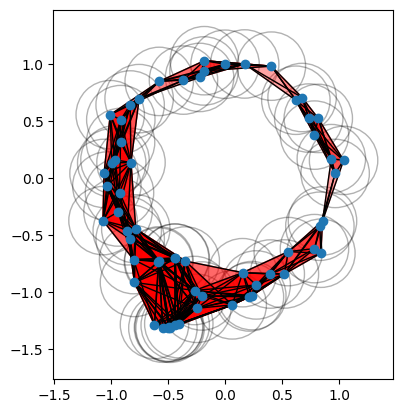

In [10]:
r_vals = 0.22   # radius parameter

points = circ1
n = len(points)

fig, ax = plt.subplots()

# Plot balls
for p in points:
    circles = plt.Circle(p, r, fill=False, alpha=0.3)
    ax.add_patch(circles)

# Plot points
ax.scatter(points[:,0], points[:,1], zorder=3)

# Compute edges (1-simplices)
edges = []
for i, j in combinations(range(n), 2):
    if np.linalg.norm(points[i] - points[j]) <= 2*r:
        edges.append((i,j))
        ax.plot([points[i,0], points[j,0]],
                [points[i,1], points[j,1]],
                linewidth=1, color="black")

# Compute triangles (2-simplices)
for i, j, k in combinations(range(n), 3):

    dij = np.linalg.norm(points[i] - points[j])
    dik = np.linalg.norm(points[i] - points[k])
    djk = np.linalg.norm(points[j] - points[k])

    if dij <= 2*r and dik <= 2*r and djk <= 2*r:

        triangle = plt.Polygon(
            [points[i], points[j], points[k]],
            alpha=0.2,
            color="red",
        )
        ax.add_patch(triangle)

ax.set_aspect('equal')
plt.show()

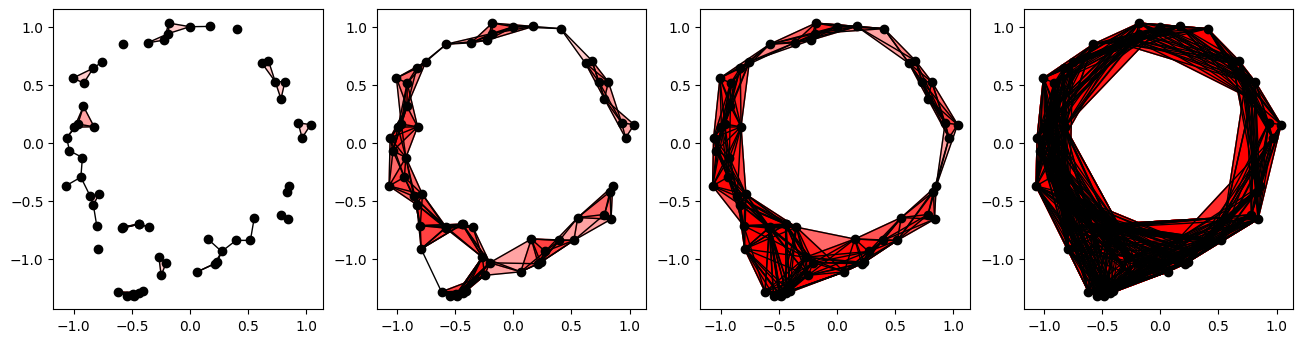

In [16]:
r_vals = [0.1, 0.21, 0.3, 0.6]   # radius parameter

points = circ1
n = len(points)

fig, ax = plt.subplots(1,4, figsize=(16,4))

# Plot balls
#for p in points:
#    circles = plt.Circle(p, r, fill=False, alpha=0.3)
#    ax.add_patch(circles)

# Plot points
for ax_i in range(4):
    ax[ax_i].scatter(points[:,0], points[:,1], zorder=3, color="black")
    #
    # Compute edges (1-simplices)
    edges = []
    for i, j in combinations(range(n), 2):
        if np.linalg.norm(points[i] - points[j]) <= 2*r_vals[ax_i]:
            edges.append((i,j))
            ax[ax_i].plot([points[i,0], points[j,0]],
                    [points[i,1], points[j,1]],
                    linewidth=1, color="black")

    # Compute triangles (2-simplices)
    for i, j, k in combinations(range(n), 3):

        dij = np.linalg.norm(points[i] - points[j])
        dik = np.linalg.norm(points[i] - points[k])
        djk = np.linalg.norm(points[j] - points[k])

        if dij <= 2*r_vals[ax_i] and dik <= 2*r_vals[ax_i] and djk <= 2*r_vals[ax_i]:

            triangle = plt.Polygon(
                [points[i], points[j], points[k]],
                alpha=0.2,
                color="red",
            )
            ax[ax_i].add_patch(triangle)

    ax[ax_i].set_aspect('equal')
plt.show()

0.0 0.007436779327690601
0.40873995423316956 0.5319309234619141


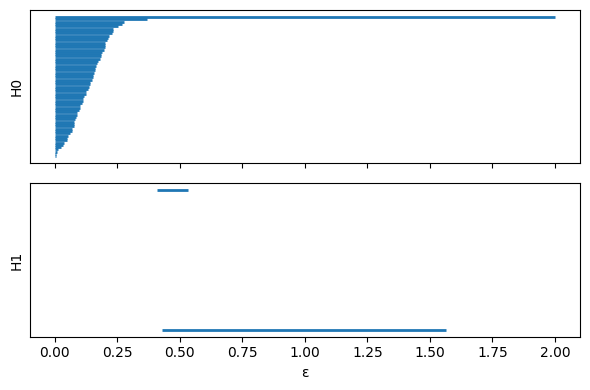

In [26]:
import matplotlib.pyplot as plt
from ripser import ripser
from persim import plot_diagrams

# compute persistent homology (VR filtration)
result = ripser(circ1, maxdim=1)

# extract persistence diagrams
diagrams = result["dgms"]

# plot barcode diagram
#plot_diagrams(diagrams, plot_only=[0,1], lifetime=False)

#plt.show()

fig, axes = plt.subplots(2, 1, figsize=(6,4), sharex=True)

for dim, ax in enumerate(axes):
    intervals = diagrams[dim]

    for i, (birth, death) in enumerate(intervals):
        if death == float("inf"):
            death = 2   # truncate infinite bars
        if i == 1:
            print(birth, death)
        ax.hlines(i, birth, death, linewidth=2)
    
    ax.set_ylabel(f"H{dim}")
    ax.set_yticks([])

axes[-1].set_xlabel("ε")

plt.tight_layout()
plt.show()